## 1. Documentação do Dataset — Customer Support Ticket Dataset

### a. Fonte (origem do dataset)

O dataset utilizado neste trabalho é o **"Customer Support Ticket Dataset"**, disponibilizado publicamente no Kaggle, no endereço:

`https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data`

Trata-se de um conjunto de dados que reúne tickets de suporte técnico ao cliente relacionados a diversos produtos de tecnologia. Por questão de privacidade, os emails utilizam um domínio genérico `@example.com`, indicando que os dados foram tratados/mascarados antes da publicação.

### b. Principais características

- **Volume**: 8.469 registros (tickets) e 17 colunas (atributos)
- **Unidade de análise**: cada linha representa um ticket de suporte único, identificado por `Ticket ID`
- **Tipos de dados presentes**:
  - **Dados demográficos do cliente**: Nome, E-mail, Idade, Gênero
  - **Dados da compra**: Produto Comprado, Data de Compra
  - **Dados do ticket**: Tipo, Assunto, Descrição (texto livre), Status, Resolução, Prioridade, Canal
  - **Dados temporais**: Tempo de Primeira Resposta, Tempo até Resolução
  - **Dados de avaliação**: Nota de Satisfação do Cliente (escala de 1 a 5)
- **Natureza mista**: combina variáveis categóricas (gênero, tipo de ticket, canal, prioridade), numéricas (idade, satisfação), textuais/livres (descrição, resolução) e temporais (datas de compra, resposta e resolução)
- **Domínio de aplicação**: suporte técnico a produtos de tecnologia: cobre problemas de hardware, bugs de software, falhas de rede, acesso a contas, perda de dados, entre outros tópicos de suporte

### c. Motivo de escolha do dataset

O dataset foi escolhido por ser adequado ao objetivo do projeto de bloco pelos seguintes motivos:

1. **Diversidade de variáveis para EDA**: combina dados categóricos, numéricos e textuais, permitindo uma análise exploratória completa (univariada, e futuramente multivariada) com variedade de gráficos e testes.
2. **Variável-alvo natural**: as colunas `Ticket Subject` ou `Ticket Type` funcionam como candidatas naturais a variável alvo, possibilitando modelar a **intenção do cliente** ao abrir um ticket, problema central que o sistema de atendimento ao cliente com IA deverá resolver.
3. **Aderência ao caso de uso do projeto**: o objetivo final do bloco é construir uma API que simula um sistema de atendimento ao cliente. Um dataset real de tickets de suporte é o insumo mais direto e coerente com esse domínio de aplicação.
4. **Tamanho adequado**: com ~8.500 registros, o volume é suficiente para análises estatísticas significativas, mas ainda gerenciável para processamento em ambiente local/Colab sem necessidade de infraestrutura pesada.

## 2. EDA Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/customer_support_tickets.csv')

### a. Compreensão do problema e do dataset

O dataset representa tickets de suporte técnico ao cliente. O problema de negócio é entender **por que** os clientes abrem tickets, ou seja, identificar a **intenção** por trás de cada solicitação (`Ticket Type` / `Ticket Subject`), a partir de atributos do cliente, do produto e da própria descrição do problema.

Colunas candidatas a variável alvo: `Ticket Type` ou `Ticket Subject`.
Colunas preditoras potenciais: `Customer Age`, `Customer Gender`, `Product Purchased`, `Ticket Channel`, `Ticket Priority`, entre outras.

### b. Inspeção inicial

In [2]:
df.shape
df.head()
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,asmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 01:21:19,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


### c. Verificação da qualidade dos dados

In [3]:
df.isnull().sum()
df.duplicated().sum()
df.dtypes

Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
dtype: object

Diferente do dataset "Adult Census Income" visto em aula, este dataset **não utiliza "?" como marcador de ausência**, os valores faltantes já aparecem como `NaN` nativo do pandas.

Os valores ausentes se concentram em três colunas: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` (5.700 nulos cada), além de `First Response Time` (2.819 nulos). Investigando a relação com `Ticket Status`, percebe-se que essa ausência **não é aleatória**, e sim estrutural, pois só existe informação de resolução/satisfação para tickets já **fechados** (`Closed`), e só existe primeira resposta para tickets que **não estão mais em aberto** (`Open`). Ou seja, o dado ausente aqui reflete o estágio do ciclo de vida do ticket, e não um erro de coleta.

Não há linhas duplicadas no dataset.

As colunas `Date of Purchase`, `First Response Time` e `Time to Resolution` estão como `object` (texto), mas representam datas/horários e devem ser convertidas para o tipo `datetime` na etapa de limpeza.

In [4]:
print(df[df['Resolution'].isnull()]['Ticket Status'].value_counts())
print()
print(df[df['Resolution'].notnull()]['Ticket Status'].value_counts())
print()
print(df[df['First Response Time'].isnull()]['Ticket Status'].value_counts())

Ticket Status
Pending Customer Response    2881
Open                         2819
Name: count, dtype: int64

Ticket Status
Closed    2769
Name: count, dtype: int64

Ticket Status
Open    2819
Name: count, dtype: int64


### d. Limpeza e preparação dos dados

In [5]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

df.dtypes
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Os valores ausentes em `Resolution`, `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating` **não serão removidos nem imputados**, pois refletem um estado legítimo do ticket (ainda não respondido/resolvido) e não um erro de qualidade. Removê-los eliminaria ~67% da base. Imputá-los criaria informação falsa (ex.: inventar uma nota de satisfação para um ticket que ainda não foi avaliado). A decisão é **manter os `NaN` como estão**, documentando seu significado.

### e. Análise Univariada

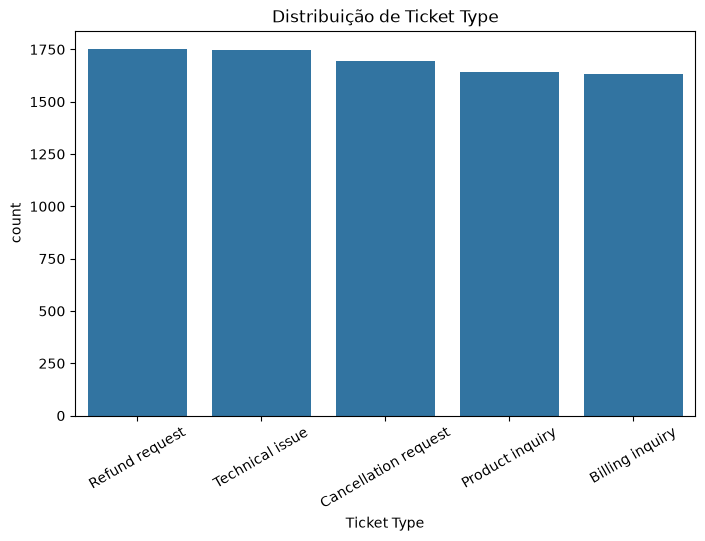

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Ticket Type', order=df['Ticket Type'].value_counts().index)
plt.title('Distribuição de Ticket Type')
plt.xticks(rotation=30)
plt.show()

df['Ticket Type'].value_counts()

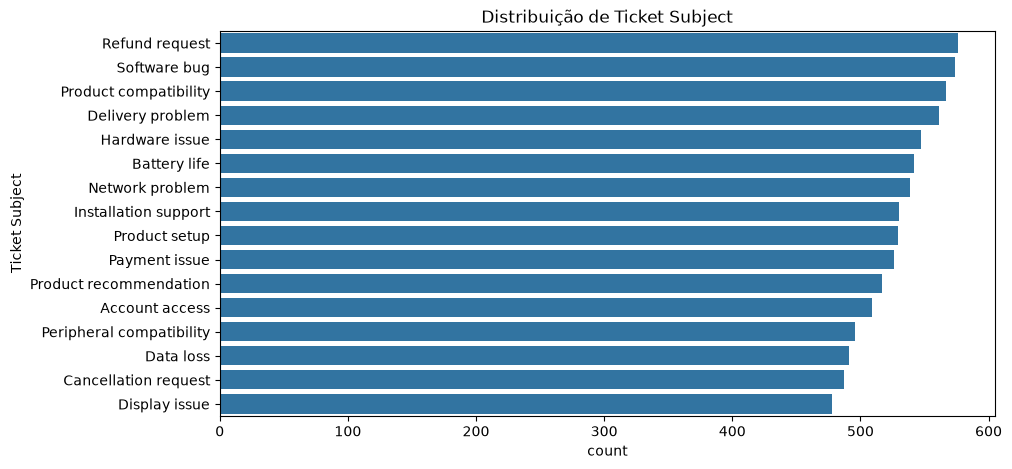

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Ticket Subject', order=df['Ticket Subject'].value_counts().index)
plt.title('Distribuição de Ticket Subject')
plt.show()

df['Ticket Subject'].value_counts()

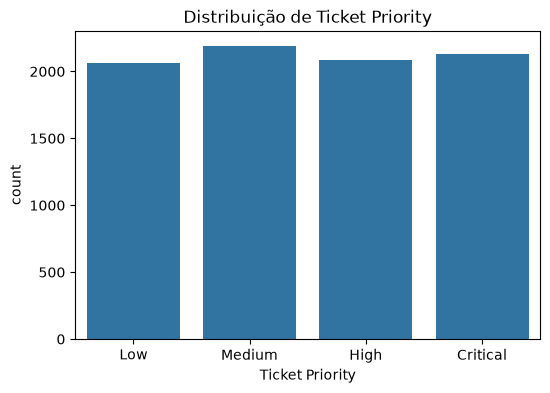

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Priority', order=['Low','Medium','High','Critical'])
plt.title('Distribuição de Ticket Priority')
plt.show()

df['Ticket Priority'].value_counts()

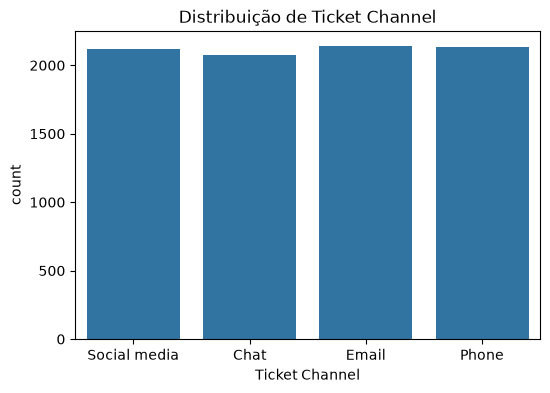

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Channel')
plt.title('Distribuição de Ticket Channel')
plt.show()

df['Ticket Channel'].value_counts()

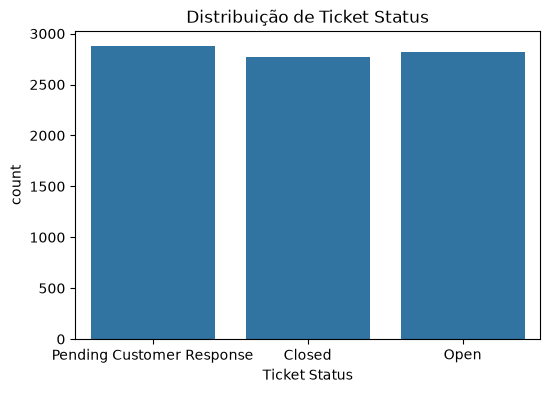

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Status')
plt.title('Distribuição de Ticket Status')
plt.show()

df['Ticket Status'].value_counts()

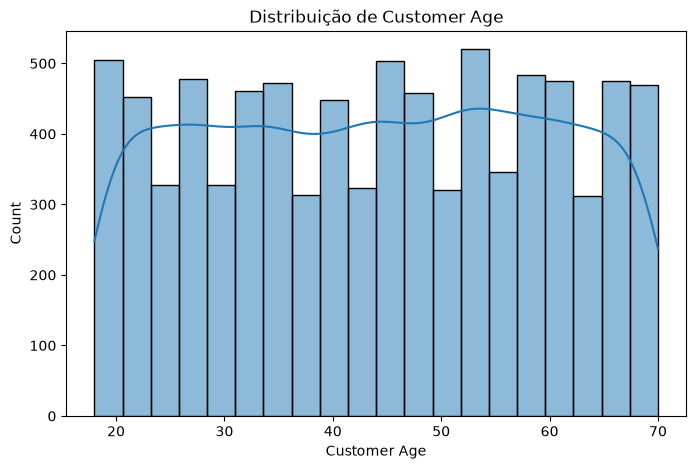

count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Customer Age'], bins=20, kde=True)
plt.title('Distribuição de Customer Age')
plt.show()

df['Customer Age'].describe()

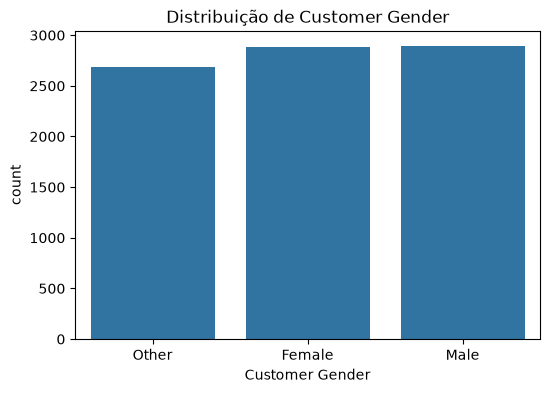

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Customer Gender')
plt.title('Distribuição de Customer Gender')
plt.show()

df['Customer Gender'].value_counts()

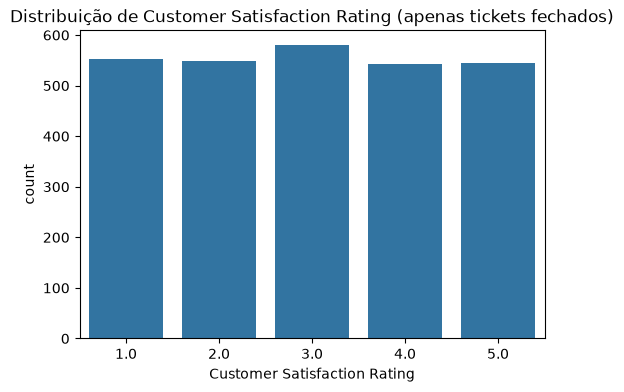

Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544
Name: count, dtype: int64

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Customer Satisfaction Rating')
plt.title('Distribuição de Customer Satisfaction Rating (apenas tickets fechados)')
plt.show()

df['Customer Satisfaction Rating'].value_counts().sort_index()

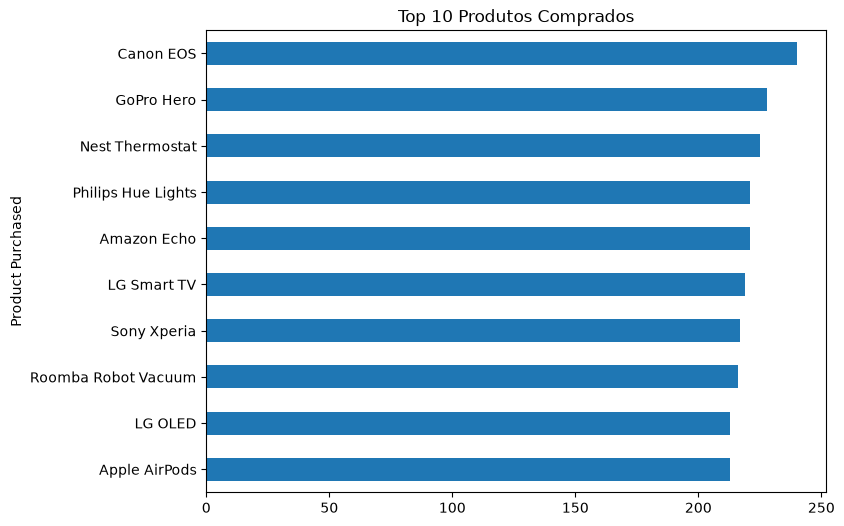

In [14]:
plt.figure(figsize=(8,6))
df['Product Purchased'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Produtos Comprados')
plt.gca().invert_yaxis()
plt.show()

**Observações da Análise Univariada:**

- `Ticket Type`, `Ticket Priority`, `Ticket Channel`, `Ticket Status`, `Customer Gender` e `Customer Satisfaction Rating` apresentam distribuições **praticamente uniformes** entre suas categorias. Não há classe dominante em nenhuma dessas variáveis. Isso é um forte indício de que o dataset foi **gerado/balanceado artificialmente**, e não coletado de um cenário real de suporte (onde normalmente há desequilíbrio, ex. mais tickets de baixa prioridade que críticos).
- `Ticket Subject` tem mais categorias (subtemas), mas ainda com frequências próximas entre si.
- `Customer Age` segue uma distribuição aproximadamente uniforme entre 18 e 70 anos, sem concentração em uma faixa etária específica.
- Os produtos comprados (`Product Purchased`) também estão bem distribuídos entre um catálogo amplo, sem um produto claramente predominante.

## 3. Hipóteses sobre as intenções dos usuários

A partir da Análise Univariada, observam-se os seguintes padrões nas distribuições das principais variáveis, que permitem levantar hipóteses sobre as intenções dos usuários ao abrir um ticket:

**Hipótese 1 — A intenção do cliente (Ticket Type) não está associada a um produto ou faixa etária específica**
Como `Ticket Type` (Refund request, Technical issue, Cancellation request, Product inquiry, Billing inquiry) apresenta frequências quase idênticas entre si, e `Customer Age` se distribui de forma uniforme entre 18 e 70 anos, a hipótese é de que a intenção do cliente **não depende do perfil demográfico** (idade) nem de um produto específico, mas sim de fatores contextuais da experiência de uso (ex.: tempo de uso do produto, tipo de defeito), que não estão representados diretamente neste conjunto de variáveis.

**Hipótese 2 — O canal de contato escolhido não reflete a urgência do problema**
A distribuição de `Ticket Channel` (Email, Phone, Social media, Chat) é praticamente uniforme, assim como `Ticket Priority` (Low, Medium, High, Critical). A hipótese é de que os clientes **não escolhem o canal com base na gravidade do problema**, ou seja, um cliente com um ticket `Critical` tem a mesma probabilidade de contatar por chat ou por telefone que um cliente com prioridade `Low`. Isso sugere que a escolha do canal está mais ligada à preferência pessoal/hábito do cliente do que à intenção ou urgência da solicitação.

**Hipótese 3 — A satisfação do cliente não está relacionada ao tipo de solicitação**
Entre os tickets fechados, `Customer Satisfaction Rating` se distribui de forma praticamente uniforme entre as notas 1 e 5, sem concentração em notas altas ou baixas. A hipótese é de que a satisfação do cliente **não depende diretamente da natureza do problema relatado** (ex.: um pedido de reembolso não gera necessariamente mais insatisfação que uma dúvida sobre produto), mas sim de fatores relacionados à qualidade do atendimento prestado durante a resolução do ticket, algo que poderá ser investigado com mais profundidade na análise multivariada.